In [1]:
import numpy as np
from tueplots import bundles
import matplotlib.pyplot as plt
import pickle
import scipy
## setting matplotlib context
from cycler import cycler
from matplotlib.cm import get_cmap
cmap = get_cmap("tab10",8)
palette = [cmap(i) for i in range(8)]
rc = bundles.neurips2024(usetex=False)
rc.update({
    # Set the line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})

/var/folders/cx/cy7pq56x7m32_zfmgnslz8cnlnlryt/T/ipykernel_72047/373850321.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10",8)


In [2]:
# import glob
# def getkey(f):
#     return int(f.split(".")[0].split("_")[-2])

# files = glob.glob("results/adult_balanced/Seed=42/T=10000/stats_target*.pkl")
# files = sorted(files,key=getkey)

# data = []
# for file in files:
#     with open(file, "rb") as f:
#         arr = pickle.load(f)
#     data.append(arr[:,:,0]) 

# stats = np.concatenate(data,axis=0)

# with open("results/adult_balanced/Seed=42/T=10000/stats_target.pkl","wb") as f:
#     pickle.dump(stats,f)

In [3]:
with open("results/adult_balanced/Seed=42/T=10000/in_indices_target.pkl","rb") as f:
    in_indices = pickle.load(f)
with open("results/adult_balanced/Seed=42/T=10000/stats_target.pkl","rb") as f:
    stats = pickle.load(f)

in_indices.shape, stats.shape

((10001, 10000), (10001, 10000))

In [4]:
# M, N = stats.shape
# assert in_indices.shape == (M, N), "in_indices must be (M, N)"
# alpha = 0.01

# mu_ins, mu_outs, sigma_ins, sigma_outs = np.zeros((M,N)), np.zeros((M,N)), np.zeros((M,N)), np.zeros((M,N))

# for j in range(M):
#     for i in range(N):
#         shadow_stats = np.concatenate([stats[:j,i], stats[j+1:,i]],axis=0)
#         shadow_idxs = np.concatenate([in_indices[:j,i], in_indices[j+1:,i]],axis=0)
        
#         mu_ins[j,i] = np.mean(shadow_stats[shadow_idxs])
#         mu_outs[j,i] = np.mean(shadow_stats[~shadow_idxs])
#         sigma_ins[j,i] = np.std(shadow_stats[shadow_idxs])
#         sigma_outs[j,i] = np.std(shadow_stats[~shadow_idxs])

In [5]:
M, N = stats.shape
assert in_indices.shape == (M, N), "in_indices must be (M, N)"

in_mask  = in_indices.astype(bool)
out_mask = ~in_mask

# ------------------------------------------------------------------
# Element-wise masks
# ------------------------------------------------------------------
stats_in  = np.where(in_mask,  stats, 0.0)   # (M, N)
stats_out = np.where(out_mask, stats, 0.0)   # (M, N)
stats_in_sq  = np.where(in_mask,  stats ** 2, 0.0)
stats_out_sq = np.where(out_mask, stats ** 2, 0.0)

col_sum_in    = stats_in.sum(axis=0)      # (N,)
col_sum_out   = stats_out.sum(axis=0)
col_sum_in_sq = stats_in_sq.sum(axis=0)
col_sum_out_sq= stats_out_sq.sum(axis=0)
col_cnt_in    = in_mask.sum(axis=0)       # (N,)  int
col_cnt_out   = out_mask.sum(axis=0)

# ------------------------------------------------------------------
# LOO sums / counts  (subtract the m-th model's contribution)
# Shapes broadcast to (M, N) automatically
# ------------------------------------------------------------------
loo_cnt_in  = col_cnt_in  - in_mask.astype(int)   # (M, N)
loo_cnt_out = col_cnt_out - out_mask.astype(int)

loo_sum_in     = col_sum_in    - stats_in          # (M, N)
loo_sum_out    = col_sum_out   - stats_out
loo_sum_in_sq  = col_sum_in_sq - stats_in_sq
loo_sum_out_sq = col_sum_out_sq- stats_out_sq

mu_ins  = loo_sum_in  / loo_cnt_in   # (M, N)
mu_outs = loo_sum_out / loo_cnt_out

sigma_ins  = np.sqrt(np.maximum(loo_sum_in_sq  / loo_cnt_in  - mu_ins  ** 2, 0.0))
sigma_outs = np.sqrt(np.maximum(loo_sum_out_sq / loo_cnt_out - mu_outs ** 2, 0.0))

# --------------------------
# Computing LLR grid
# --------------------------

def get_llr(t, mu_in, mu_out, sigma_in, sigma_out):
    return np.log(sigma_in) - np.log(sigma_out) + 0.5 * (t - mu_out)**2/ sigma_out**2 - 0.5 * (t - mu_in)**2/ sigma_in**2

llr_grid = get_llr(stats, mu_ins, mu_outs, sigma_ins, sigma_outs)

In [6]:
# --------------------------
# Computing PP Stats Grid
# --------------------------
delta_mu = mu_ins - mu_outs
stats_pp = (np.sign(delta_mu) * (stats - mu_outs)) / sigma_outs

In [7]:
Ms = np.arange(1,6)*1000
alpha = 0.01

TPR_concat, TPR_concat_pp, TPR_px, TPR_px_ana = np.zeros(len(Ms)), np.zeros(len(Ms)),np.zeros(len(Ms)), np.zeros(len(Ms))
for i in range(len(Ms)):
    M_i = Ms[i] * 2
    curr_stats_pp, curr_in_indices, curr_llrs = stats_pp[:M_i,:], in_indices[:M_i,:], llr_grid[:M_i,:]
    
    mask_out = ~curr_in_indices
    mask_in  = curr_in_indices

    tau_px = np.nanquantile(np.where(mask_out, curr_llrs, np.nan), 1 - alpha, axis=0)
    tpr_px = (((curr_llrs > tau_px) & mask_in).sum(axis=0)
                / mask_in.sum(axis=0))
    TPR_px[i] = tpr_px.mean()

    tau_all = np.nanquantile(np.where(mask_out, curr_llrs, np.nan), 1 - alpha)

    tpr_all = ((curr_llrs > tau_all) & mask_in).sum() / mask_in.sum()
    TPR_concat[i] = tpr_all

    tau_all_pp = np.nanquantile(np.where(mask_out, curr_stats_pp, np.nan), 1 - alpha)
    tpr_all_pp = ((curr_stats_pp > tau_all_pp) & mask_in).sum() / mask_in.sum()
    TPR_concat_pp[i] = tpr_all_pp

    tau_analytical = scipy.stats.norm.ppf(1-alpha)
    tpr_px_ana = (((curr_stats_pp > tau_analytical) & mask_in).sum(axis=0)
                / mask_in.sum(axis=0))
    TPR_px_ana[i] = tpr_px_ana.mean()
    

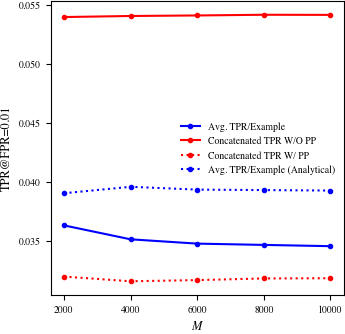

In [8]:
with plt.rc_context(rc):
    fig ,ax = plt.subplots(1,1)
    ax.plot(2*Ms, TPR_px, color="b",marker=".",label="Avg. TPR/Example")
    ax.plot(2*Ms, TPR_concat,color="r",marker=".", label="Concatenated TPR W/O PP")
    ax.plot(2*Ms, TPR_concat_pp,color="r", linestyle=":",marker=".",label="Concatenated TPR W/ PP")
    ax.plot(2*Ms, TPR_px_ana,color="b", linestyle=":",marker=".",label="Avg. TPR/Example (Analytical)")
    ax.set(xlabel=r"$M$",ylabel=f"TPR@FPR={alpha}", xticks=2*Ms)
    ax.legend()
    ax.set_box_aspect(1)
    # plt.savefig(f"lira_N_{N}_N_train_{N//2}_fpr_{alpha}_v2.pdf",bbox_inches="tight")
    plt.show()

In [11]:
# -----------------------------------------------------------
# Comparing PX-FPRs Using W/ and W/O PP concantenated taus
# -----------------------------------------------------------

tau_pp = np.nanquantile(np.where(~in_indices, stats_pp, np.nan), 1 - alpha)

fpr_px_pp = (((stats_pp > tau_pp) & ~in_indices).sum(axis=0)
            / (~in_indices).sum(axis=0))

tau = np.nanquantile(np.where(~in_indices, llr_grid, np.nan), 1 - alpha)

fpr_px = (((llr_grid > tau) & ~in_indices).sum(axis=0)
            / (~in_indices).sum(axis=0))


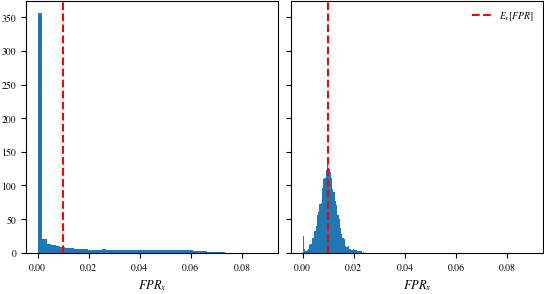

In [12]:
with plt.rc_context(rc):
    fig, ax = plt.subplots(1,2,sharex="row",sharey="row")
    ax[0].hist(fpr_px,bins=50,density=True)
    ax[0].axvline(x=0.01,color="r",linestyle="--",label=rf"$E_x[FPR]$")
    ax[0].set(xlabel=rf"$FPR_x$")
    ax[0].set_box_aspect(1)

    ax[1].hist(fpr_px_pp,bins=50,density=True)
    ax[1].axvline(x=0.01,color="r",linestyle="--",label=rf"$E_x[FPR]$")
    ax[1].set(xlabel=rf"$FPR_x$")
    ax[1].set_box_aspect(1)
    
    ax[1].legend()
    # plt.savefig("px_fprs_at_concat_tau.pdf",bbox_inches="tight")
    plt.show()